# CIEM5220 — Wind & Waves: Dynamic Analysis of an Offshore Wind Turbine
**Group 4** | Single consolidated notebook (Steps 1–8).

Parameters: M = 600 t, water depth h = 36 m, hub height H = 108 m, Ω_max = 7.6 rpm,
fetch F = 180 km, U₁₀(LC2) = 19 m/s.

All quantities flow in-kernel (no intermediate files). Detailed write-up lives in `report/`.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from numpy.linalg import cholesky
from scipy.linalg import eigh
from scipy.optimize import brentq
from dynamics_tools import (shape_functions, element_stiffness, element_mass,
                            S_jonswap, wave_numbers)

# ====== GEOMETRY & MATERIAL ========
E   = 210e9      # Young's modulus [Pa]
rho = 7850       # steel density [kg/m^3]
Hw  = 36.0       # water depth h [m]
Ha  = 108.0      # hub height H [m]
L   = Hw + Ha    # total beam length [m]
M_nacelle = 6e5  # RNA mass [kg] (600 t, point mass - no rotary inertia)

# ====== DISCRETISATION ========
elements = 12
le       = L/elements
elem_w   = int(Hw/le)          # submerged elements
elem_a   = elements - elem_w   # air elements
nodes    = elements + 1
ndof     = 2*nodes
z_nodes  = np.arange(nodes)*le
z_above  = z_nodes - Hw        # height above waterline (>0 = in air)
air_nodes = np.where(z_above > 0)[0]

# ====== ROTOR PARAMETERS ========
Omega_max = 7.6
f_1P = Omega_max/60
f_3P = 3*f_1P
f_target = 1.1*f_1P
Dt_ratio = 90

print(f"1P={f_1P:.4f} Hz  3P={f_3P:.4f} Hz  target f1 (>=1.1*1P)={f_target:.4f} Hz")
print(f"le={le} m, elem_w={elem_w}, elem_a={elem_a}, ndof={ndof}")

1P=0.1267 Hz  3P=0.3800 Hz  target f1 (>=1.1*1P)=0.1393 Hz
le=12.0 m, elem_w=3, elem_a=9, ndof=26


## Step 1–2 — Finite-element model and diameter tuning
**Objective.** Euler–Bernoulli cantilever (12 elements) with a point tip mass (RNA), clamped
at the seabed; build K, M, C and tune the diameter so f₁ ≥ 1.1·f_1P with D/t ∈ [80,120].
**Key assumptions.** Linear elastic, small displacements, clamped base, RNA = point mass
(no rotary inertia), Rayleigh damping = 2% in modes 1 & 2.

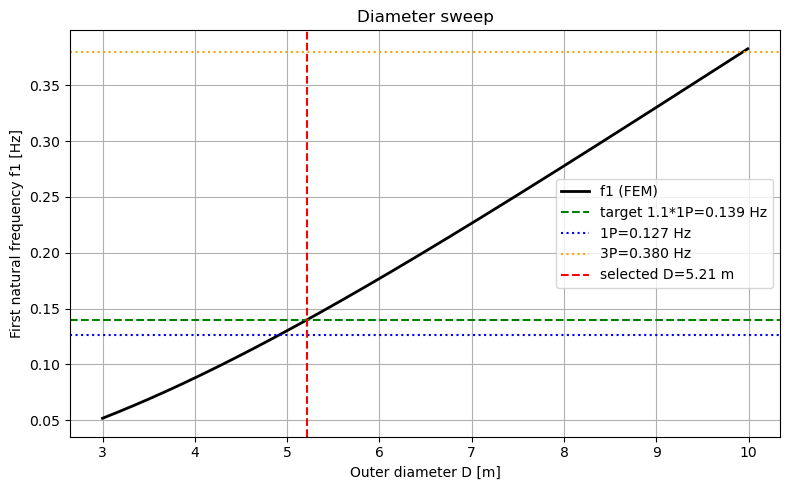

Selected D=5.21 m, t=0.0579 m, D/t=90


In [2]:
# ====== PARAMETRIC FE BUILDER ========
def build_fem(D0):
    t  = D0/Dt_ratio
    Di = D0 - 2*t
    A  = np.pi/4*(D0**2 - Di**2)
    I  = np.pi/64*(D0**4 - Di**4)
    Ke = element_stiffness(le, E*I)
    Me = element_mass(le, rho*A)
    K = np.zeros((ndof, ndof)); M = np.zeros((ndof, ndof))
    for e in range(elements):
        dofs = [2*e, 2*e+1, 2*e+2, 2*e+3]
        for i in range(4):
            for j in range(4):
                K[dofs[i], dofs[j]] += Ke[i, j]
                M[dofs[i], dofs[j]] += Me[i, j]
    M[ndof-2, ndof-2] += M_nacelle          # RNA point mass on tip translational DOF
    free = np.arange(2, ndof)               # clamp base (remove DOF 0,1)
    return K[np.ix_(free, free)], M[np.ix_(free, free)], A, I

# ====== DIAMETER TUNING (sweep) ========
D0_range = np.arange(3.0, 10.0, 0.01)
f1_list = []
D0 = None
for D0_try in D0_range:
    Kf, Mf, _, _ = build_fem(D0_try)
    f1_try = np.sqrt(eigh(Kf, Mf, eigvals_only=True)[0])/(2*np.pi)
    f1_list.append(f1_try)
    if f1_try >= f_target and D0 is None:
        D0 = round(D0_try, 2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(D0_range, f1_list, 'k', lw=2, label='f1 (FEM)')
ax.axhline(f_target, color='green', ls='--', label=f'target 1.1*1P={f_target:.3f} Hz')
ax.axhline(f_1P, color='blue', ls=':', label=f'1P={f_1P:.3f} Hz')
ax.axhline(f_3P, color='orange', ls=':', label=f'3P={f_3P:.3f} Hz')
ax.axvline(D0, color='red', ls='--', label=f'selected D={D0:.2f} m')
ax.set_xlabel('Outer diameter D [m]'); ax.set_ylabel('First natural frequency f1 [Hz]')
ax.set_title('Diameter sweep'); ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

print(f"Selected D={D0} m, t={D0/Dt_ratio:.4f} m, D/t={Dt_ratio}")

In [3]:
# ====== FINAL MODEL ========
K_free, M_free, A, I = build_fem(D0)
EI = E*I; rhoA = rho*A
t_wall = D0/Dt_ratio

# ====== EIGENVALUE ANALYSIS ========
eigvals, eigvecs = eigh(K_free, M_free)
omega = np.sqrt(eigvals)
freq  = omega/(2*np.pi)
f1, f2 = freq[0], freq[1]
T1 = 1/f1

print(f"A={A:.3f} m^2, I={I:.3f} m^4, M symmetric? {np.allclose(M_free, M_free.T)}")
print(f"f1={f1:.4f} Hz (T1={T1:.2f} s)   f2={f2:.4f} Hz   f3={freq[2]:.4f} Hz")
print(f"margin above 1P: {(f1/f_1P-1)*100:.1f}%   soft-stiff (1P<f1<3P): {f_1P<f1<f_3P}")

A=0.937 m^2, I=3.109 m^4, M symmetric? True
f1=0.1397 Hz (T1=7.16 s)   f2=1.2122 Hz   f3=3.7262 Hz
margin above 1P: 10.3%   soft-stiff (1P<f1<3P): True


In [4]:
# ====== RAYLEIGH DAMPING (2% in modes 1 & 2) ========
zeta = 0.02
w1, w2 = omega[0], omega[1]
alpha = 2*w1*w2*(zeta*w2 - zeta*w1)/(w2**2 - w1**2)
beta  = 2*(zeta*w2 - zeta*w1)/(w2**2 - w1**2)
C_free = alpha*M_free + beta*K_free
print(f"alpha={alpha:.5f}, beta={beta:.5f}")
print(f"check zeta: mode1={(alpha/(2*w1)+beta*w1/2)*100:.2f}%  mode2={(alpha/(2*w2)+beta*w2/2)*100:.2f}%")

alpha=0.03148, beta=0.00471
check zeta: mode1=2.00%  mode2=2.00%


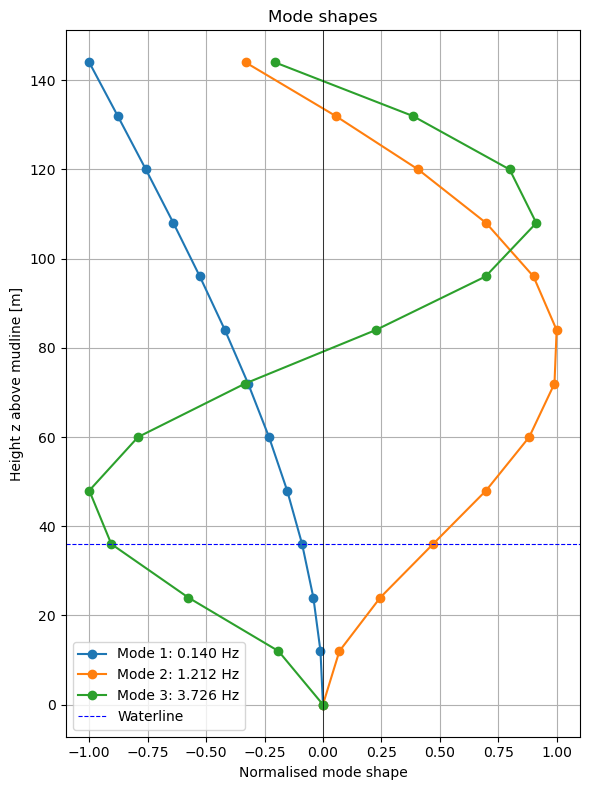

In [5]:
# ====== MODE SHAPES (first 3) ========
fig, ax = plt.subplots(figsize=(6, 8))
for mode in range(3):
    phi = eigvecs[:, mode]
    phi_lat = np.concatenate([[0], phi[0::2]])      # prepend clamped base
    phi_lat = phi_lat/np.max(np.abs(phi_lat))       # normalise
    ax.plot(phi_lat, z_nodes, marker='o', label=f'Mode {mode+1}: {freq[mode]:.3f} Hz')
ax.axhline(Hw, color='blue', ls='--', lw=0.8, label='Waterline')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Normalised mode shape'); ax.set_ylabel('Height z above mudline [m]')
ax.set_title('Mode shapes'); ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

In [6]:
# ====== STATIC SANITY CHECK (uniform load, no tip mass) ========
# analytical cantilever: u_tip = qL^4/(8EI), M_mud = qL^2/2
x = sp.Symbol('x')
B = shape_functions(le)
q = 1e3
f_chk = np.zeros(ndof)
for e in range(elements):
    fe = [float(sp.integrate(Ni*q, (x, 0, le))) for Ni in B]
    for i in range(4):
        f_chk[2*e+i] += fe[i]
u_chk = np.linalg.solve(K_free, f_chk[2:])
u_tip_FE = u_chk[-2]
u_e0 = np.concatenate([[0, 0], u_chk[:2]])
M_mud_FE = EI*sum(float(sp.diff(Ni, x, 2).subs(x, 0))*u_e0[i] for i, Ni in enumerate(B))
print(f"tip deflection : FE={u_tip_FE:.6f} m   analytical={q*L**4/(8*EI):.6f} m")
print(f"mudline moment : FE={M_mud_FE/1e6:.3f} MNm   analytical={q*L**2/2/1e6:.3f} MNm")

tip deflection : FE=0.082314 m   analytical=0.082314 m
mudline moment : FE=10.356 MNm   analytical=10.368 MNm


## Step 3 — Wind and wave (co-)spectra
**Objective.** Define the two load cases (fetch coupling), the mean wind profile, Kaimal
turbulence spectra + vertical coherence, and JONSWAP wave spectra with significant heights.

A single simulation grid with **Δf = 1/T** is defined here and reused for synthesis (Step 4),
so the generated signals are aperiodic over the window and the spectra/time-series are
consistent. The frequency axis starts at Δf (not an arbitrary cut-off) to retain the
low-frequency turbulence variance.

In [7]:
# ====== SIMULATION GRID (df = 1/T) ========
g = 9.81
T_total = 900.0
dt      = 0.05
N_t     = int(round(T_total/dt))
df      = 1.0/T_total
f_max   = 2.0
N_freq  = int(f_max/df)
f_axis    = np.arange(1, N_freq+1)*df     # harmonics of 1/T, start at df
omega_axis = 2*np.pi*f_axis
domega    = omega_axis[1] - omega_axis[0]
t_axis    = np.arange(N_t)*dt
print(f"T={T_total}s dt={dt}s N_t={N_t}  df={df:.5f}Hz N_freq={N_freq}")
print(f"Nyquist={1/(2*dt):.1f}Hz, signal period 1/df={1/df:.0f}s (= T, no repetition)")

# Diffraction onset: Morison theory is valid for D/lambda < 0.2 (assessed in Step 8).
# The wave loading is applied only within this band; the sea state carries negligible
# energy above it, and short waves (lambda < 5D) do not load the cylinder via Morison.
k_diff = 2*np.pi/(5*D0)
f_diff = np.sqrt(g*k_diff*np.tanh(k_diff*Hw))/(2*np.pi)
wave_band = (f_axis <= f_diff).astype(float)
print(f"wave loading limited to f <= f_diff = {f_diff:.3f} Hz (D/lambda=0.2 diffraction onset)")

T=900.0s dt=0.05s N_t=18000  df=0.00111Hz N_freq=1800
Nyquist=10.0Hz, signal period 1/df=900s (= T, no repetition)
wave loading limited to f <= f_diff = 0.245 Hz (D/lambda=0.2 diffraction onset)


In [8]:
# ====== LOAD CASES (fetch-limited coupling) ========
F_fetch = 180e3
z0 = 0.001
def Tp_of_U(U): return 0.286*(g*F_fetch/U**2)**0.33*U/g    # 0.286 = 1/3.5
def Hs_of_U(U): return 0.0016*np.sqrt(g*F_fetch/U**2)*U**2/g

# LC2: U10 given -> derive Tp, Hs
U10_LC2 = 19.0
Tp_LC2, Hs_LC2 = Tp_of_U(U10_LC2), Hs_of_U(U10_LC2)
# LC1: Tp = T1 (resonance) -> derive U10, Hs
Tp_LC1 = T1
U10_LC1 = brentq(lambda U: Tp_of_U(U) - Tp_LC1, 1.0, 50.0)
Hs_LC1 = Hs_of_U(U10_LC1)
print(f"LC1 (resonance):  U10={U10_LC1:.2f} m/s  Tp={Tp_LC1:.2f} s  Hs={Hs_LC1:.2f} m")
print(f"LC2 (operational): U10={U10_LC2:.2f} m/s  Tp={Tp_LC2:.2f} s  Hs={Hs_LC2:.2f} m")

LC1 (resonance):  U10=9.26 m/s  Tp=7.16 s  Hs=2.01 m
LC2 (operational): U10=19.00 m/s  Tp=9.14 s  Hs=4.12 m


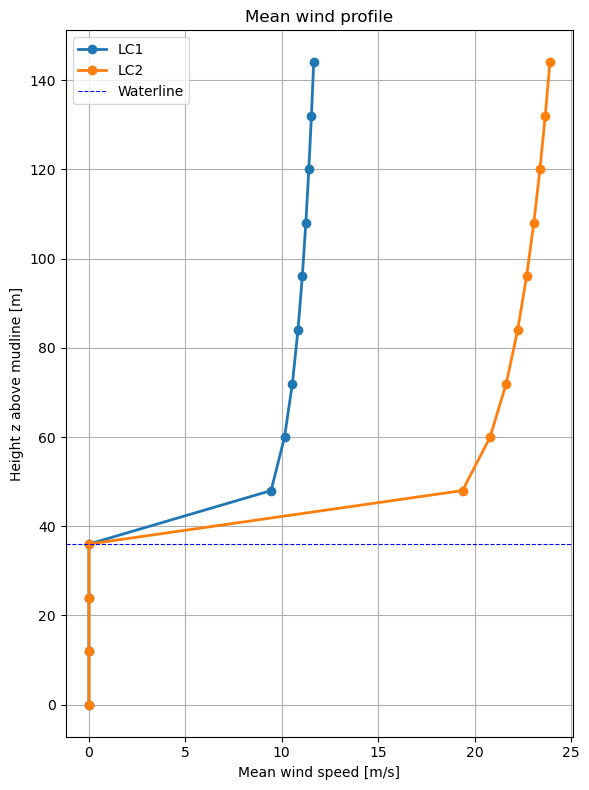

hub mean wind: LC1=11.66 m/s, LC2=23.91 m/s


In [9]:
# ====== MEAN WIND PROFILE (log law) ========
def mean_wind(U10, z):
    return np.where(z > 0, U10*np.log(np.maximum(z, z0)/z0)/np.log(10.0/z0), 0.0)
U_mean_LC1 = mean_wind(U10_LC1, z_above)
U_mean_LC2 = mean_wind(U10_LC2, z_above)

fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(U_mean_LC1, z_nodes, lw=2, marker='o', label='LC1')
ax.plot(U_mean_LC2, z_nodes, lw=2, marker='o', label='LC2')
ax.axhline(Hw, color='blue', ls='--', lw=0.8, label='Waterline')
ax.set_xlabel('Mean wind speed [m/s]'); ax.set_ylabel('Height z above mudline [m]')
ax.set_title('Mean wind profile'); ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()
print(f"hub mean wind: LC1={U_mean_LC1[-1]:.2f} m/s, LC2={U_mean_LC2[-1]:.2f} m/s")

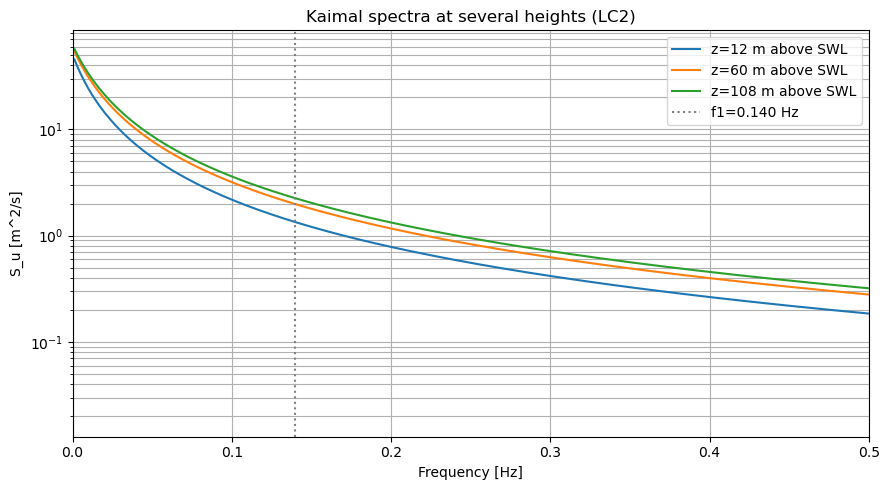

hub sigma_u (integrated) LC1=0.677 (theory 0.699)


In [10]:
# ====== KAIMAL TURBULENCE SPECTRA (per air node) ========
I_u = 0.06        # turbulence intensity
L_u = 180.0       # integral length scale [m]
def kaimal(f, U):
    sigma = I_u*U
    return 4*sigma**2*(L_u/U)/(1 + 6*f*L_u/U)**(5/3)

n_air = len(air_nodes)
S_kaimal_LC1 = np.array([kaimal(f_axis, U_mean_LC1[n]) for n in air_nodes])
S_kaimal_LC2 = np.array([kaimal(f_axis, U_mean_LC2[n]) for n in air_nodes])

# plot at several heights (LC2)
fig, ax = plt.subplots(figsize=(9, 5))
for idx in [0, n_air//2, n_air-1]:
    z = z_above[air_nodes[idx]]
    ax.semilogy(f_axis, S_kaimal_LC2[idx], label=f'z={z:.0f} m above SWL')
ax.axvline(f1, color='gray', ls=':', label=f'f1={f1:.3f} Hz')
ax.set_xlim(0, 0.5); ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('S_u [m^2/s]')
ax.set_title('Kaimal spectra at several heights (LC2)'); ax.legend(); ax.grid(True, which='both')
plt.tight_layout(); plt.show()
print(f"hub sigma_u (integrated) LC1={np.sqrt(np.sum(S_kaimal_LC1[-1]*df)):.3f} (theory {I_u*U_mean_LC1[-1]:.3f})")

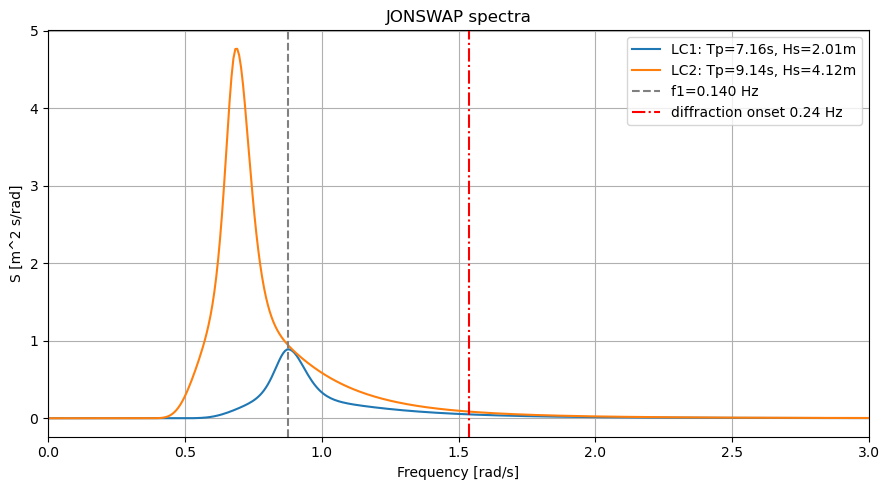

Hs check: LC1=2.008 m, LC2=4.118 m


In [11]:
# ====== JONSWAP WAVE SPECTRA (alpha fitted to Hs) ========
gamma = 3.3
omega_p_LC1 = 2*np.pi/Tp_LC1
omega_p_LC2 = 2*np.pi/Tp_LC2
def fit_alpha(Hs_target, omega_p):
    a = 0.0081
    for _ in range(100):
        S = S_jonswap(a, omega_axis, omega_p, gamma)
        a *= (Hs_target/(4*np.sqrt(np.sum(S*domega))))**2
    return a
alpha_LC1 = fit_alpha(Hs_LC1, omega_p_LC1)
alpha_LC2 = fit_alpha(Hs_LC2, omega_p_LC2)
S_jonswap_LC1 = S_jonswap(alpha_LC1, omega_axis, omega_p_LC1, gamma)
S_jonswap_LC2 = S_jonswap(alpha_LC2, omega_axis, omega_p_LC2, gamma)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(omega_axis, S_jonswap_LC1, label=f'LC1: Tp={Tp_LC1:.2f}s, Hs={Hs_LC1:.2f}m')
ax.plot(omega_axis, S_jonswap_LC2, label=f'LC2: Tp={Tp_LC2:.2f}s, Hs={Hs_LC2:.2f}m')
ax.axvline(2*np.pi*f1, color='gray', ls='--', label=f'f1={f1:.3f} Hz')
ax.axvline(2*np.pi*f_diff, color='red', ls='-.', label=f'diffraction onset {f_diff:.2f} Hz')
ax.set_xlim(0, 3); ax.set_xlabel('Frequency [rad/s]'); ax.set_ylabel('S [m^2 s/rad]')
ax.set_title('JONSWAP spectra'); ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()
print(f"Hs check: LC1={4*np.sqrt(np.sum(S_jonswap_LC1*domega)):.3f} m, LC2={4*np.sqrt(np.sum(S_jonswap_LC2*domega)):.3f} m")

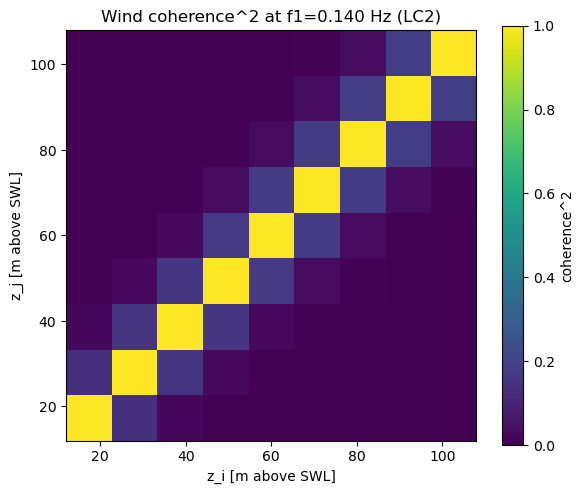

In [12]:
# ====== WIND CO-SPECTRA (Davenport coherence) ========
a_coh = 12.0
za = z_above[air_nodes]
DZ = np.abs(za[:, None] - za[None, :])
def coherence_matrix(f, Uair):
    Uavg = 0.5*(Uair[:, None] + Uair[None, :])
    return np.exp(-a_coh*f*DZ/Uavg)

# magnitude-squared coherence heatmap at f1 (LC2)
gam = coherence_matrix(f1, U_mean_LC2[air_nodes])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(gam**2, origin='lower', cmap='viridis', vmin=0, vmax=1,
               extent=[za[0], za[-1], za[0], za[-1]])
ax.set_xlabel('z_i [m above SWL]'); ax.set_ylabel('z_j [m above SWL]')
ax.set_title(f'Wind coherence^2 at f1={f1:.3f} Hz (LC2)')
plt.colorbar(im, ax=ax, label='coherence^2'); plt.tight_layout(); plt.show()

## Step 4 — Time-series generation
**Objective.** Synthesise wind and wave kinematics at every node from the spectra (random
phases), then verify statistics and convergence.

Synthesis uses Δf = 1/T (aperiodic over the window). Wind fluctuations are made **spatially
coherent across height** via Cholesky factorisation of the coherence matrix; wave kinematics
follow linear (Airy) theory with the finite-depth dispersion relation. A single fixed seed
makes the realisation reproducible.

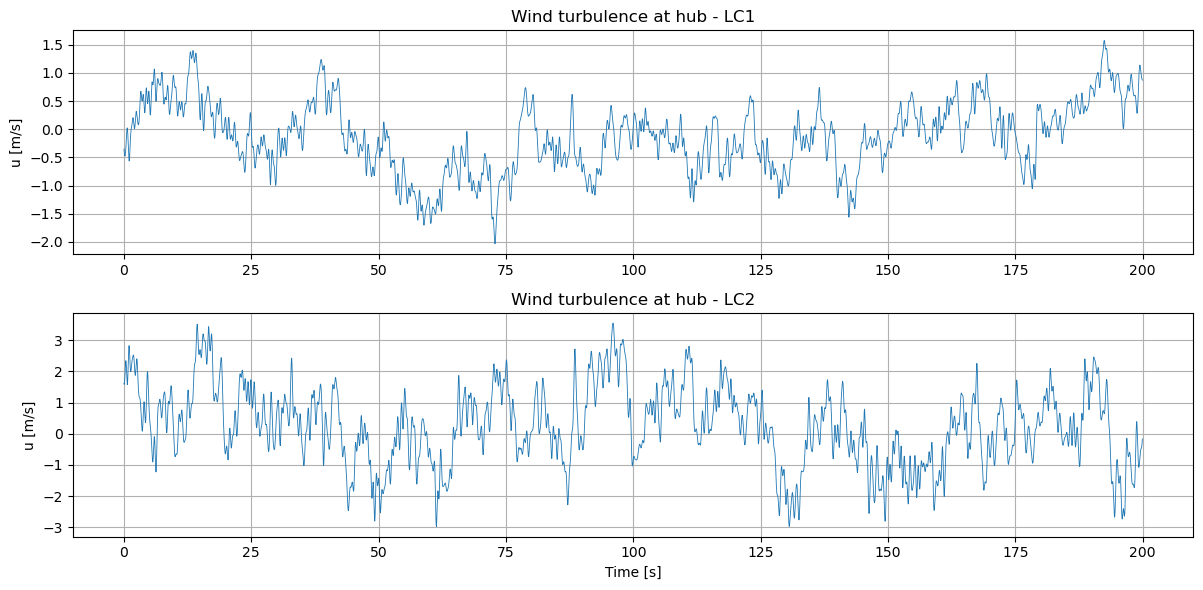

hub std: LC1=0.625 (spectral 0.677)
         LC2=1.294 (spectral 1.387)
(single-realisation std scatters ~+/-9% around the spectral value; mean over seeds is unbiased)


In [13]:
# ====== WIND TIME SERIES (Cholesky coherence) ======
np.random.seed(17)
def wind_timeseries(Uair, S_kaimal):
    Uavg = 0.5*(Uair[:, None] + Uair[None, :])
    Bc = np.zeros((n_air, N_freq), complex)
    for k in range(N_freq):
        Sd  = S_kaimal[:, k]
        Gam = np.exp(-a_coh*f_axis[k]*DZ/Uavg)            # coherence at this frequency
        Sig = np.sqrt(np.outer(Sd, Sd))*Gam               # cross-spectral matrix
        Lc  = cholesky(Sig + 1e-12*np.eye(n_air))         # Cholesky factor
        w   = np.exp(1j*np.random.uniform(0, 2*np.pi, n_air))
        Bc[:, k] = np.sqrt(2*df)*(Lc @ w)                 # correlated nodal amplitudes
    u = np.zeros((n_air, N_t))
    for i in range(n_air):
        u[i] = (np.abs(Bc[i])[:, None] *
                np.cos(2*np.pi*f_axis[:, None]*t_axis[None, :] + np.angle(Bc[i])[:, None])).sum(0)
    return u
u_wind_LC1 = wind_timeseries(U_mean_LC1[air_nodes], S_kaimal_LC1)
u_wind_LC2 = wind_timeseries(U_mean_LC2[air_nodes], S_kaimal_LC2)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for ax, u, lab in zip(axes, [u_wind_LC1, u_wind_LC2], ['LC1', 'LC2']):
    ax.plot(t_axis[:4000], u[-1, :4000], lw=0.6)
    ax.set_ylabel('u [m/s]'); ax.set_title(f'Wind turbulence at hub - {lab}'); ax.grid(True)
axes[1].set_xlabel('Time [s]'); plt.tight_layout(); plt.show()
print(f"hub std: LC1={u_wind_LC1[-1].std():.3f} (spectral {np.sqrt(np.sum(S_kaimal_LC1[-1]*df)):.3f})")
print(f"         LC2={u_wind_LC2[-1].std():.3f} (spectral {np.sqrt(np.sum(S_kaimal_LC2[-1]*df)):.3f})")
print("(single-realisation std scatters ~+/-9% around the spectral value; mean over seeds is unbiased)")

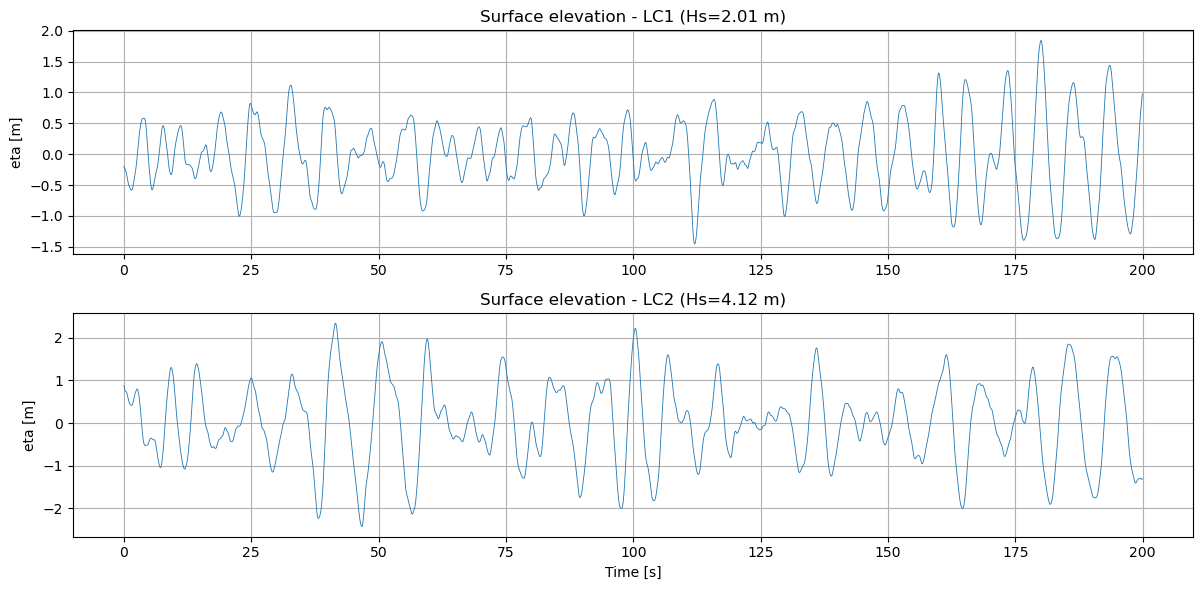

Hs (4*std): LC1=2.008 m (target 2.008), LC2=4.118 m (target 4.118)


In [14]:
# ====== WAVE SURFACE ELEVATION ======
A_wave_LC1 = np.sqrt(2*S_jonswap_LC1*domega)
A_wave_LC2 = np.sqrt(2*S_jonswap_LC2*domega)
phi_LC1 = np.random.uniform(0, 2*np.pi, N_freq)
phi_LC2 = np.random.uniform(0, 2*np.pi, N_freq)
eta_LC1 = (A_wave_LC1[:, None]*np.cos(omega_axis[:, None]*t_axis[None, :] + phi_LC1[:, None])).sum(0)
eta_LC2 = (A_wave_LC2[:, None]*np.cos(omega_axis[:, None]*t_axis[None, :] + phi_LC2[:, None])).sum(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for ax, eta, lab, Hs in zip(axes, [eta_LC1, eta_LC2], ['LC1', 'LC2'], [Hs_LC1, Hs_LC2]):
    ax.plot(t_axis[:4000], eta[:4000], lw=0.6)
    ax.set_ylabel('eta [m]'); ax.set_title(f'Surface elevation - {lab} (Hs={Hs:.2f} m)'); ax.grid(True)
axes[1].set_xlabel('Time [s]'); plt.tight_layout(); plt.show()
print(f"Hs (4*std): LC1={4*eta_LC1.std():.3f} m (target {Hs_LC1:.3f}), LC2={4*eta_LC2.std():.3f} m (target {Hs_LC2:.3f})")

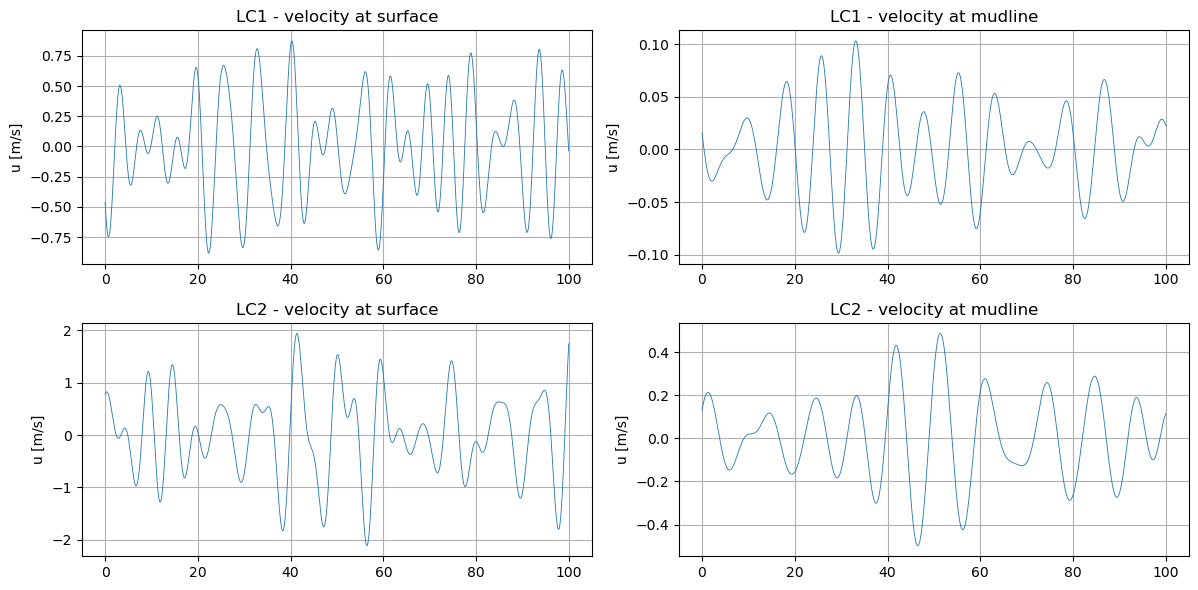

umax surface: LC1=1.664 m/s, LC2=3.069 m/s


In [15]:
# ====== WATER PARTICLE KINEMATICS (Airy, overflow-safe depth factor) ======
h = Hw
k_arr = wave_numbers(omega_axis, h)
kh = k_arr*h
def depth_factor(z_from_surface):   # cosh(k(z+h))/sinh(kh) without overflow; z_from_surface <= 0
    kz = k_arr*z_from_surface
    return np.exp(kz)*(1 + np.exp(-2*(kz + kh)))/(1 - np.exp(-2*kh))

z_sub = z_nodes[:elem_w+1]
n_sub = len(z_sub)
u_water_LC1 = np.zeros((n_sub, N_t));  du_water_LC1 = np.zeros((n_sub, N_t))
u_water_LC2 = np.zeros((n_sub, N_t));  du_water_LC2 = np.zeros((n_sub, N_t))
for i, zi in enumerate(z_sub):
    dfac = depth_factor(zi - h)
    c1 = np.cos(omega_axis[:, None]*t_axis[None, :] + phi_LC1[:, None])
    s1 = np.sin(omega_axis[:, None]*t_axis[None, :] + phi_LC1[:, None])
    c2 = np.cos(omega_axis[:, None]*t_axis[None, :] + phi_LC2[:, None])
    s2 = np.sin(omega_axis[:, None]*t_axis[None, :] + phi_LC2[:, None])
    amp1 = (A_wave_LC1*wave_band*omega_axis*dfac)[:, None]   # band-limited to diffraction-valid range
    amp2 = (A_wave_LC2*wave_band*omega_axis*dfac)[:, None]
    u_water_LC1[i]  = (amp1*c1).sum(0);   du_water_LC1[i] = (-amp1*omega_axis[:, None]*s1).sum(0)
    u_water_LC2[i]  = (amp2*c2).sum(0);   du_water_LC2[i] = (-amp2*omega_axis[:, None]*s2).sum(0)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for r, (u, lab) in enumerate([(u_water_LC1, 'LC1'), (u_water_LC2, 'LC2')]):
    axes[r, 0].plot(t_axis[:2000], u[-1, :2000], lw=0.6); axes[r, 0].set_title(f'{lab} - velocity at surface')
    axes[r, 1].plot(t_axis[:2000], u[0, :2000], lw=0.6);  axes[r, 1].set_title(f'{lab} - velocity at mudline')
    for c in range(2): axes[r, c].set_ylabel('u [m/s]'); axes[r, c].grid(True)
plt.tight_layout(); plt.show()
print(f"umax surface: LC1={np.abs(u_water_LC1[-1]).max():.3f} m/s, LC2={np.abs(u_water_LC2[-1]).max():.3f} m/s")

In [16]:
# ====== KEULEGAN-CARPENTER NUMBERS (drag relevance) ======
print("KC = umax*Tp/D  (KC<~3 inertia-dominated -> drag minor; >3 drag matters)")
print(f"{'z from SWL [m]':>15} {'KC LC1':>8} {'KC LC2':>8}")
for i, zi in enumerate(z_sub):
    KC1 = np.abs(u_water_LC1[i]).max()*Tp_LC1/D0
    KC2 = np.abs(u_water_LC2[i]).max()*Tp_LC2/D0
    print(f"{zi-h:>15.0f} {KC1:>8.2f} {KC2:>8.2f}")
print("-> KC exceeds 3 near the surface (esp. LC2): drag is retained in the time-domain model.")

KC = umax*Tp/D  (KC<~3 inertia-dominated -> drag minor; >3 drag matters)
 z from SWL [m]   KC LC1   KC LC2
            -36     0.19     1.38
            -24     0.28     1.68
            -12     0.70     2.75
              0     2.29     5.38
-> KC exceeds 3 near the surface (esp. LC2): drag is retained in the time-domain model.


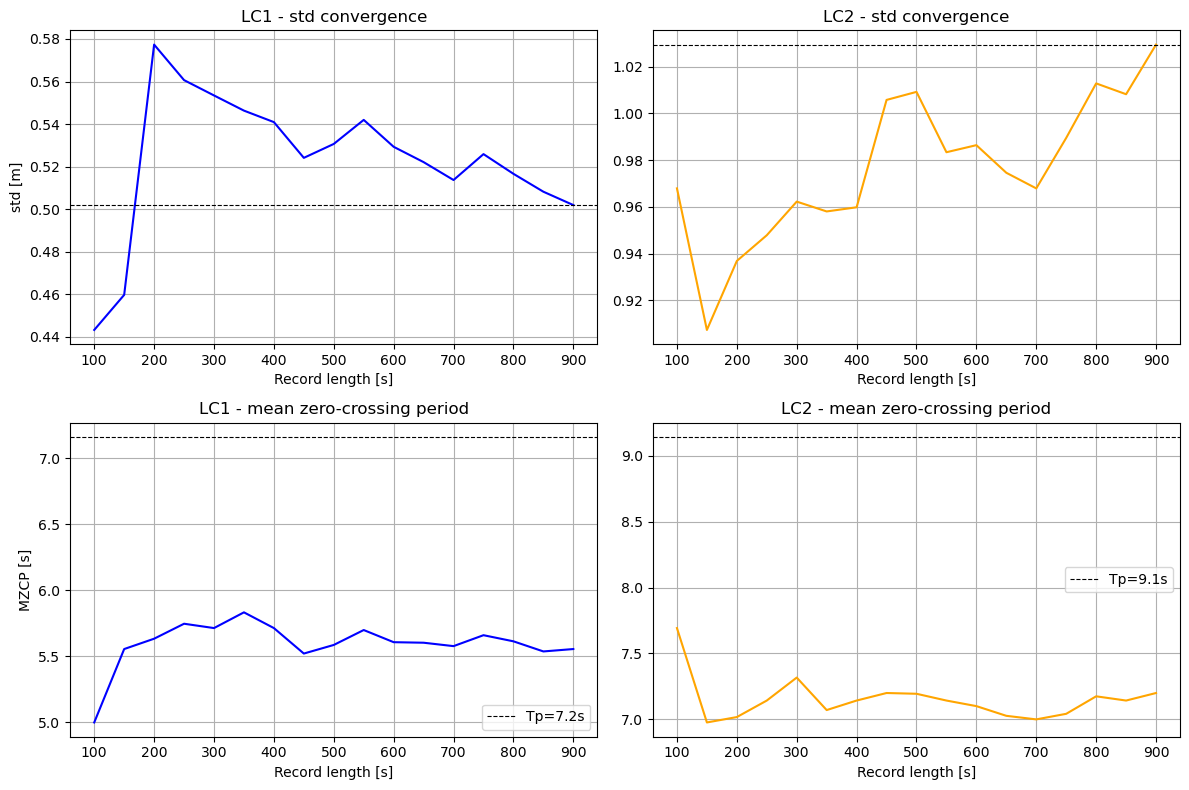

final std:  LC1=0.502 m,  LC2=1.029 m
final MZCP: LC1=5.56 s,  LC2=7.20 s


In [17]:
# ====== CONVERGENCE ANALYSIS (surface elevation) ======
def mzcp(sig):
    zc = np.where(np.diff(np.sign(sig)))[0]
    return 2*len(sig)*dt/len(zc) if len(zc) > 1 else np.nan
T_lengths = np.arange(100, int(T_total)+1, 50)
std1 = [eta_LC1[:int(T/dt)].std() for T in T_lengths]
std2 = [eta_LC2[:int(T/dt)].std() for T in T_lengths]
mz1  = [mzcp(eta_LC1[:int(T/dt)]) for T in T_lengths]
mz2  = [mzcp(eta_LC2[:int(T/dt)]) for T in T_lengths]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(T_lengths, std1, 'b'); axes[0, 0].axhline(eta_LC1.std(), color='k', ls='--', lw=0.8)
axes[0, 0].set_title('LC1 - std convergence'); axes[0, 0].set_ylabel('std [m]')
axes[0, 1].plot(T_lengths, std2, 'orange'); axes[0, 1].axhline(eta_LC2.std(), color='k', ls='--', lw=0.8)
axes[0, 1].set_title('LC2 - std convergence')
axes[1, 0].plot(T_lengths, mz1, 'b'); axes[1, 0].axhline(Tp_LC1, color='k', ls='--', lw=0.8, label=f'Tp={Tp_LC1:.1f}s')
axes[1, 0].set_title('LC1 - mean zero-crossing period'); axes[1, 0].set_ylabel('MZCP [s]'); axes[1, 0].legend()
axes[1, 1].plot(T_lengths, mz2, 'orange'); axes[1, 1].axhline(Tp_LC2, color='k', ls='--', lw=0.8, label=f'Tp={Tp_LC2:.1f}s')
axes[1, 1].set_title('LC2 - mean zero-crossing period'); axes[1, 1].legend()
for ax in axes.flat: ax.set_xlabel('Record length [s]'); ax.grid(True)
plt.tight_layout(); plt.show()
print(f"final std:  LC1={std1[-1]:.3f} m,  LC2={std2[-1]:.3f} m")
print(f"final MZCP: LC1={mz1[-1]:.2f} s,  LC2={mz2[-1]:.2f} s")

## Step 5 — Frequency-domain analysis of the linear system
**Objective.** Linearise the wind and wave loads (freeze the structural motion), form their
load spectra at each node, and compute the one-sided PSD of the mudline bending moment.

**Method.** (i) Frequency-response function `H(ω)` from the dynamic stiffness
`Z(ω) = −ω²M + iωC + K`; (ii) wave loading via linearised Morison **inertia** (drag is
nonlinear and retained in the time domain, Step 6 — justified by KC); (iii) wind loading via
drag linearised about the mean profile; (iv) `S_MM(ω) = Σ_ij H_i S_FF,ij H_j*`. Distributed
loads are converted to nodal loads with the element tributary length so the result is directly
comparable to the time domain.

In [18]:
# ====== FREQUENCY RESPONSE FUNCTION (mudline moment per unit nodal force) ======
n_free = K_free.shape[0]
e_moment = np.zeros(n_free)
e_moment[0] = EI*6/le**2     # w1  coefficient  = EI*N3''(0)
e_moment[1] = EI*(-2)/le     # th1 coefficient  = EI*N4''(0)   (theta_1, not theta_0)

H_moment = np.zeros((n_free, N_freq), complex)
for k, wk in enumerate(omega_axis):
    Z = -wk**2*M_free + 1j*wk*C_free + K_free
    H_moment[:, k] = e_moment @ np.linalg.solve(Z, np.eye(n_free))
print(f"FRF assembled, shape {H_moment.shape}")
print(f"peak |H| at f={f_axis[np.argmax(np.abs(H_moment).max(0))]:.3f} Hz (f1={f1:.3f})")

FRF assembled, shape (24, 1800)
peak |H| at f=0.140 Hz (f1=0.140)


In [19]:
# ====== LINEARISED LOAD PARAMETERS ======
rho_air, Cd_wind = 1.25, 0.8     # air density, tower drag coeff
rho_w,   Cm      = 1025.0, 2.0   # seawater density, Morison inertia coeff

# ====== MUDLINE-MOMENT SPECTRUM ======
# WAVE: inertia-only Morison, fully coherent (single wave process) -> coherent transfer.
#       nodal force per submerged element = (per-length force)*le, split le/2 to each node.
def wave_moment_spectrum(S_eta):
    G = np.zeros(N_freq, complex)
    for e in range(elem_w):
        dfac_avg = 0.5*(depth_factor(e*le - h) + depth_factor((e+1)*le - h))
        alpha = rho_w*Cm*np.pi*D0**2/4 * omega_axis**2 * dfac_avg   # omega^2 (acceleration)
        for nd in (e, e+1):
            fi = 2*nd - 2
            if fi < 0:           # clamped mudline node carries no work
                continue
            G += H_moment[fi]*alpha*le/2
    return np.abs(G)**2 * S_eta * wave_band     # Morison valid only below diffraction onset

# WIND: cross-spectral sum over air nodes (force transfer x velocity co-spectrum).
def wind_moment_spectrum(U_mean_arr):
    T = {}                       # nodal wind-force transfer  T_n = rho_air Cd D U_n * tributary
    for e in range(elem_w, elements):
        for nd in (e, e+1):
            if U_mean_arr[nd] <= 0:
                continue
            T[nd] = T.get(nd, 0.0) + rho_air*Cd_wind*D0*U_mean_arr[nd]*le/2
    nds = list(T)
    S = np.zeros(N_freq)
    for ni in nds:
        for nj in nds:
            coh = np.exp(-a_coh*f_axis*abs(z_above[ni]-z_above[nj]) /
                         (0.5*(U_mean_arr[ni]+U_mean_arr[nj])))
            Sco = np.sqrt(kaimal(f_axis, U_mean_arr[ni])*kaimal(f_axis, U_mean_arr[nj]))*coh
            S += np.real(H_moment[2*ni-2]*np.conj(H_moment[2*nj-2]))*T[ni]*T[nj]*Sco
    return S

S_MM_wave_LC1 = wave_moment_spectrum(S_jonswap_LC1)
S_MM_wave_LC2 = wave_moment_spectrum(S_jonswap_LC2)
S_MM_wind_LC1 = wind_moment_spectrum(U_mean_LC1)
S_MM_wind_LC2 = wind_moment_spectrum(U_mean_LC2)
S_MM_LC1 = S_MM_wave_LC1 + S_MM_wind_LC1
S_MM_LC2 = S_MM_wave_LC2 + S_MM_wind_LC2
print("mudline-moment spectra assembled (wind + wave)")

mudline-moment spectra assembled (wind + wave)


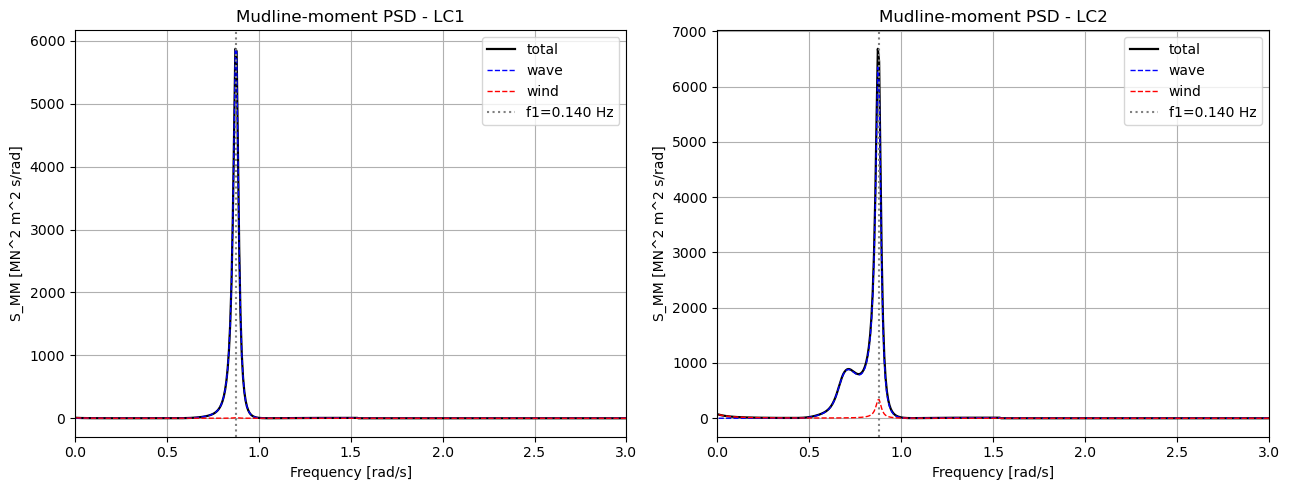

In [20]:
# ====== PLOT: MUDLINE-MOMENT PSD ======
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tot, wav, wnd, lab in [(axes[0], S_MM_LC1, S_MM_wave_LC1, S_MM_wind_LC1, 'LC1'),
                               (axes[1], S_MM_LC2, S_MM_wave_LC2, S_MM_wind_LC2, 'LC2')]:
    ax.plot(omega_axis, tot/1e12, 'k', lw=1.6, label='total')
    ax.plot(omega_axis, wav/1e12, 'b--', lw=1, label='wave')
    ax.plot(omega_axis, wnd/1e12, 'r--', lw=1, label='wind')
    ax.axvline(2*np.pi*f1, color='gray', ls=':', label=f'f1={f1:.3f} Hz')
    ax.set_xlim(0, 3); ax.set_xlabel('Frequency [rad/s]')
    ax.set_ylabel('S_MM [MN^2 m^2 s/rad]'); ax.set_title(f'Mudline-moment PSD - {lab}')
    ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

In [21]:
# ====== STATISTICAL QUANTITIES ======
def spectral_stats(S_MM):
    m0 = np.trapz(S_MM, omega_axis)
    m2 = np.trapz(omega_axis**2*S_MM, omega_axis)
    return np.sqrt(m0), 2*np.pi*np.sqrt(m0/m2)        # std, mean zero-crossing period

# mean (static) mudline moment from the mean wind drag (frequency domain gives only the
# fluctuating part; the mean must be added separately for the time-domain comparison)
def mean_mudline_moment(U_mean_arr):
    Mm = 0.0
    for e in range(elem_w, elements):
        for nd in (e, e+1):
            if U_mean_arr[nd] <= 0:
                continue
            Mm += 0.5*rho_air*Cd_wind*D0*U_mean_arr[nd]**2*le/2 * z_nodes[nd]
    return Mm

std_f_LC1, Tz_f_LC1 = spectral_stats(S_MM_LC1)
std_f_LC2, Tz_f_LC2 = spectral_stats(S_MM_LC2)
M_mean_LC1 = mean_mudline_moment(U_mean_LC1)
M_mean_LC2 = mean_mudline_moment(U_mean_LC2)

print(f"{'':12}{'std [MNm]':>12}{'Tz [s]':>10}{'mean [MNm]':>12}")
print(f"{'LC1':12}{std_f_LC1/1e6:>12.2f}{Tz_f_LC1:>10.2f}{M_mean_LC1/1e6:>12.2f}")
print(f"{'LC2':12}{std_f_LC2/1e6:>12.2f}{Tz_f_LC2:>10.2f}{M_mean_LC2/1e6:>12.2f}")
print(f"\nwave/wind split (std): LC1 wave={np.sqrt(np.trapz(S_MM_wave_LC1,omega_axis))/1e6:.2f} "
      f"wind={np.sqrt(np.trapz(S_MM_wind_LC1,omega_axis))/1e6:.2f} MNm | "
      f"LC2 wave={np.sqrt(np.trapz(S_MM_wave_LC2,omega_axis))/1e6:.2f} "
      f"wind={np.sqrt(np.trapz(S_MM_wind_LC2,omega_axis))/1e6:.2f} MNm")

               std [MNm]    Tz [s]  mean [MNm]
LC1                16.70      7.19        3.02
LC2                22.13      7.55       12.72

wave/wind split (std): LC1 wave=16.67 wind=0.94 MNm | LC2 wave=21.52 wind=5.17 MNm


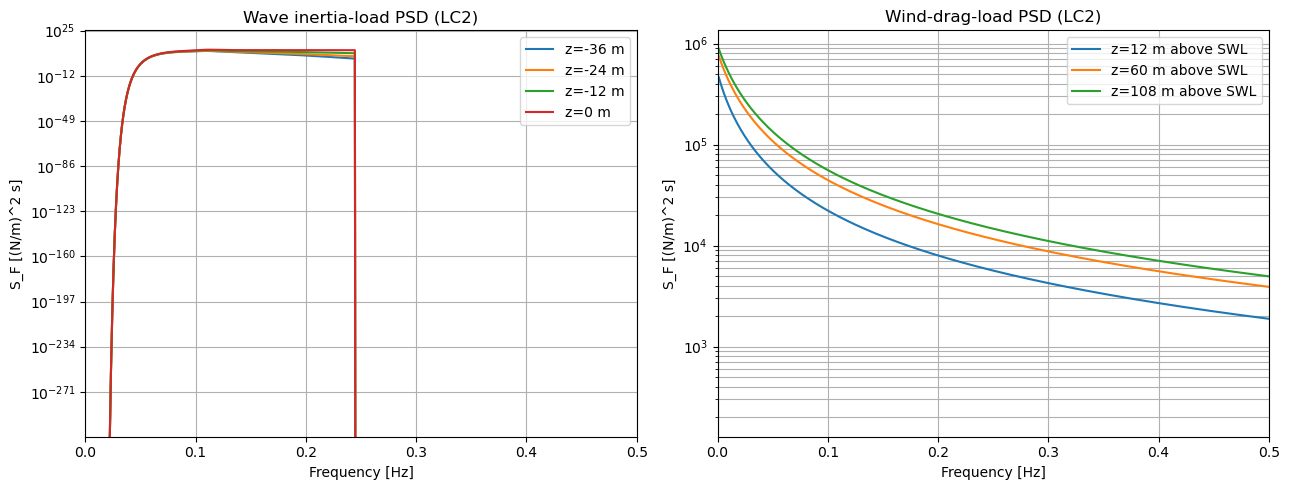

In [22]:
# ====== FORCE SPECTRA ALONG THE TOWER (LC2) ======
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nd in range(elem_w+1):                       # submerged nodes
    S_F = (rho_w*Cm*np.pi*D0**2/4*omega_axis**2*depth_factor(z_nodes[nd]-h))**2 * S_jonswap_LC2 * wave_band
    axes[0].semilogy(f_axis, S_F, label=f'z={z_nodes[nd]-h:.0f} m')
axes[0].set_xlim(0, 0.5); axes[0].set_title('Wave inertia-load PSD (LC2)')
axes[0].set_xlabel('Frequency [Hz]'); axes[0].set_ylabel('S_F [(N/m)^2 s]'); axes[0].legend(); axes[0].grid(True, which='both')
for idx in [0, n_air//2, n_air-1]:               # air nodes
    nd = air_nodes[idx]
    S_F = (rho_air*Cd_wind*D0*U_mean_LC2[nd])**2 * S_kaimal_LC2[idx]
    axes[1].semilogy(f_axis, S_F, label=f'z={z_above[nd]:.0f} m above SWL')
axes[1].set_xlim(0, 0.5); axes[1].set_title('Wind-drag-load PSD (LC2)')
axes[1].set_xlabel('Frequency [Hz]'); axes[1].set_ylabel('S_F [(N/m)^2 s]'); axes[1].legend(); axes[1].grid(True, which='both')
plt.tight_layout(); plt.show()

## Step 6 — Time-domain analysis of the nonlinear system
**Objective.** Simulate the mudline moment in the time domain with the **nonlinear** forcing
that includes **relative kinematics**: Morison drag on the relative water–structure velocity,
and aerodynamic drag on the relative wind–structure velocity. This adds the hydro/aerodynamic
damping that the linear frequency-domain analysis omits.

**Method.** Newmark-β (average acceleration, unconditionally stable). The wave kinematics are
the diffraction-band-limited fields from Step 4. The mudline moment uses the same curvature
operator as Step 5, so the two domains are directly comparable.

In [23]:
# ====== NONLINEAR FORCE ROUTINE (relative kinematics) ======
from scipy.linalg import solve as lin_solve
from scipy.signal import welch
Cd_wave = 1.0                       # wave drag coefficient

# full-node turbulence lookup (zero below the waterline)
u_wind_full_LC1 = np.zeros((nodes, N_t)); u_wind_full_LC2 = np.zeros((nodes, N_t))
for i, n in enumerate(air_nodes):
    u_wind_full_LC1[n] = u_wind_LC1[i]
    u_wind_full_LC2[n] = u_wind_LC2[i]

def compute_forces(v_full, u_water, du_water, u_wind_full, U_mean, step, nonlinear=True):
    f = np.zeros(ndof)
    # wave: Morison inertia + drag on relative velocity (submerged elements)
    for e in range(elem_w):
        u_w  = 0.5*(u_water[e, step]  + u_water[e+1, step])
        du_w = 0.5*(du_water[e, step] + du_water[e+1, step])
        v_s  = 0.5*(v_full[2*e] + v_full[2*(e+1)]) if nonlinear else 0.0
        u_rel = u_w - v_s
        F = (rho_w*Cm*np.pi*D0**2/4*du_w + 0.5*rho_w*Cd_wave*D0*u_rel*abs(u_rel))*le
        f[2*e] += F/2; f[2*(e+1)] += F/2
    # wind: drag on relative velocity (air elements)
    for e in range(elem_w, elements):
        U_avg = 0.5*(U_mean[e] + U_mean[e+1])
        u_avg = 0.5*(u_wind_full[e, step] + u_wind_full[e+1, step])
        v_s   = 0.5*(v_full[2*e] + v_full[2*(e+1)]) if nonlinear else 0.0
        U_rel = U_avg + u_avg - v_s
        F = 0.5*rho_air*Cd_wind*D0*U_rel*abs(U_rel)*le
        f[2*e] += F/2; f[2*(e+1)] += F/2
    return f

# Newmark-beta (average acceleration)
gamma_nm, beta_nm = 0.5, 0.25
K_eff = K_free + gamma_nm/(beta_nm*dt)*C_free + 1/(beta_nm*dt**2)*M_free

def time_integrate(u_water, du_water, u_wind_full, U_mean, nonlinear=True):
    u = np.zeros(n_free); v = np.zeros(n_free); acc = np.zeros(n_free)
    v_full = np.zeros(ndof)
    M_mud = np.zeros(N_t); u_top = np.zeros(N_t)
    for step in range(N_t):
        fext = compute_forces(v_full, u_water, du_water, u_wind_full, U_mean, step, nonlinear)[2:]
        feff = (fext
                + M_free @ (1/(beta_nm*dt**2)*u + 1/(beta_nm*dt)*v + (1/(2*beta_nm)-1)*acc)
                + C_free @ (gamma_nm/(beta_nm*dt)*u - (1-gamma_nm/beta_nm)*v
                            - dt*(1-gamma_nm/(2*beta_nm))*acc))
        u_new = lin_solve(K_eff, feff)
        acc_new = 1/(beta_nm*dt**2)*(u_new-u) - 1/(beta_nm*dt)*v - (1/(2*beta_nm)-1)*acc
        v_new = v + dt*((1-gamma_nm)*acc + gamma_nm*acc_new)
        M_mud[step] = e_moment @ u_new
        u_top[step] = u_new[-2]
        u, v, acc = u_new, v_new, acc_new
        v_full[2:] = v
    return M_mud, u_top

M_mud_LC1, utop_LC1 = time_integrate(u_water_LC1, du_water_LC1, u_wind_full_LC1, U_mean_LC1)
M_mud_LC2, utop_LC2 = time_integrate(u_water_LC2, du_water_LC2, u_wind_full_LC2, U_mean_LC2)
print(f"LC1: std={M_mud_LC1.std()/1e6:.2f} MNm  mean={M_mud_LC1.mean()/1e6:.2f} MNm  max={np.abs(M_mud_LC1).max()/1e6:.2f}")
print(f"LC2: std={M_mud_LC2.std()/1e6:.2f} MNm  mean={M_mud_LC2.mean()/1e6:.2f} MNm  max={np.abs(M_mud_LC2).max()/1e6:.2f}")

LC1: std=16.13 MNm  mean=3.00 MNm  max=50.58
LC2: std=19.85 MNm  mean=12.58 MNm  max=92.96


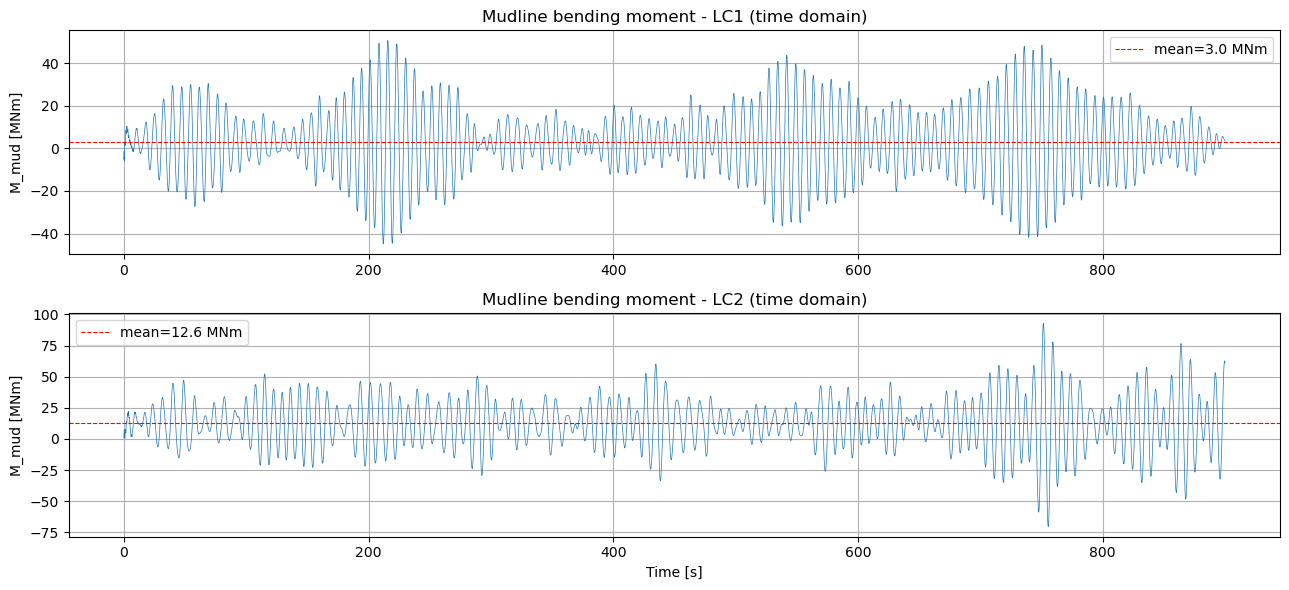

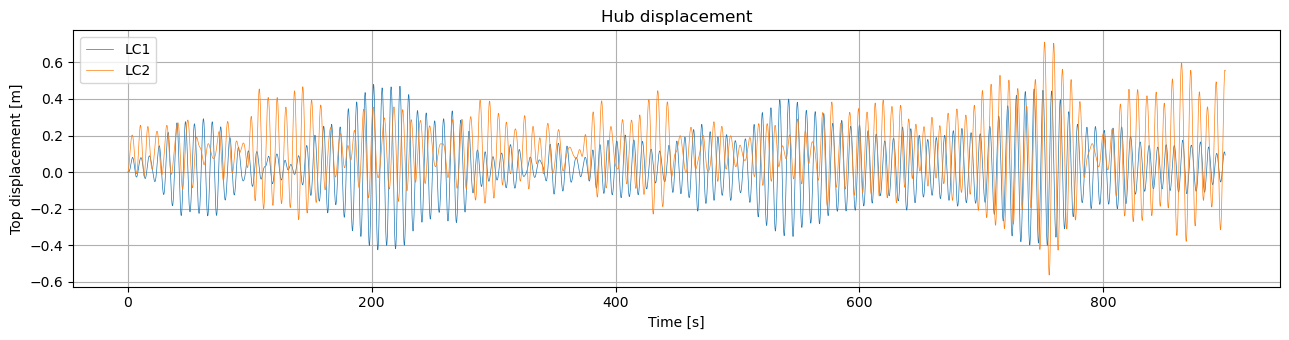

In [24]:
# ====== MUDLINE-MOMENT TIME SERIES ======
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
for ax, M, lab in zip(axes, [M_mud_LC1, M_mud_LC2], ['LC1', 'LC2']):
    ax.plot(t_axis, M/1e6, lw=0.5)
    ax.axhline(M.mean()/1e6, color='r', ls='--', lw=0.8, label=f'mean={M.mean()/1e6:.1f} MNm')
    ax.set_ylabel('M_mud [MNm]'); ax.set_title(f'Mudline bending moment - {lab} (time domain)')
    ax.legend(); ax.grid(True)
axes[1].set_xlabel('Time [s]'); plt.tight_layout(); plt.show()

# top-node displacement
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(t_axis, utop_LC1, lw=0.5, label='LC1')
ax.plot(t_axis, utop_LC2, lw=0.5, label='LC2')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Top displacement [m]')
ax.set_title('Hub displacement'); ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

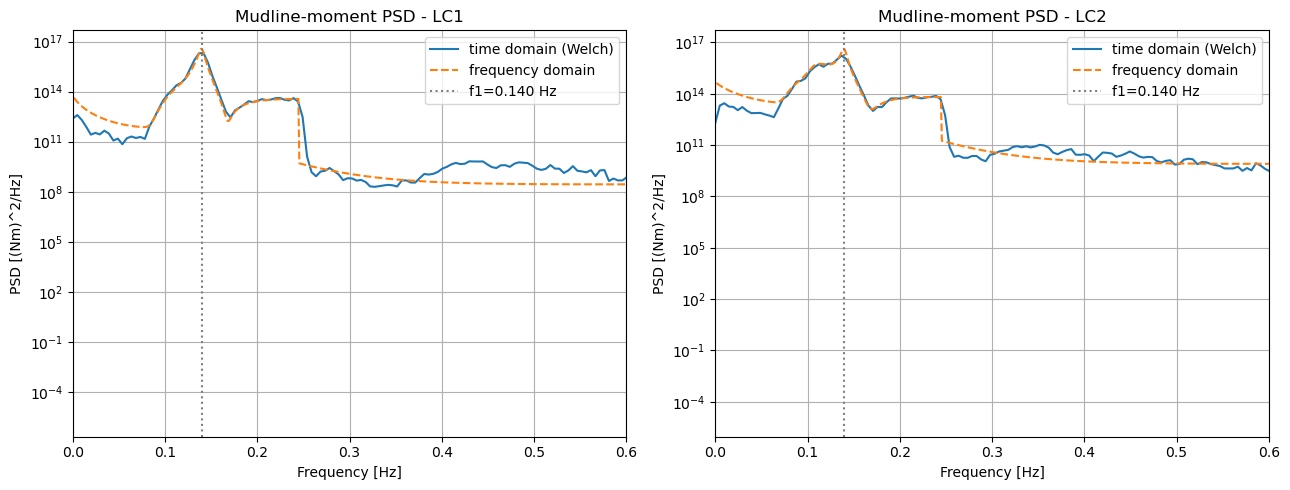

In [25]:
# ====== PSD: TIME DOMAIN (Welch) vs FREQUENCY DOMAIN ======
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, M, S_MM, lab in [(axes[0], M_mud_LC1, S_MM_LC1, 'LC1'), (axes[1], M_mud_LC2, S_MM_LC2, 'LC2')]:
    fw, Pw = welch(M - M.mean(), fs=1/dt, nperseg=4096)
    ax.semilogy(fw, Pw, label='time domain (Welch)')
    ax.semilogy(f_axis, S_MM*2*np.pi, '--', label='frequency domain')   # per-rad/s -> per-Hz
    ax.axvline(f1, color='gray', ls=':', label=f'f1={f1:.3f} Hz')
    ax.set_xlim(0, 0.6); ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('PSD [(Nm)^2/Hz]')
    ax.set_title(f'Mudline-moment PSD - {lab}'); ax.legend(); ax.grid(True, which='both')
plt.tight_layout(); plt.show()

In [26]:
# ====== TIME-DOMAIN STATISTICS ======
def tz_series(M):
    Md = M - M.mean()
    zc = np.where(np.diff(np.sign(Md)))[0]
    return 2*len(Md)*dt/len(zc)

print(f"{'':6}{'std [MNm]':>11}{'mean [MNm]':>12}{'max [MNm]':>11}{'min [MNm]':>11}{'Tz [s]':>9}")
for lab, M in [('LC1', M_mud_LC1), ('LC2', M_mud_LC2)]:
    print(f"{lab:6}{M.std()/1e6:>11.2f}{M.mean()/1e6:>12.2f}{M.max()/1e6:>11.2f}{M.min()/1e6:>11.2f}{tz_series(M):>9.2f}")

std_t_LC1, std_t_LC2 = M_mud_LC1.std(), M_mud_LC2.std()
print(f"\nfreq-domain std for comparison (Step 5): LC1={std_f_LC1/1e6:.2f}, LC2={std_f_LC2/1e6:.2f} MNm")
print(f"time vs freq std ratio: LC1={std_t_LC1/std_f_LC1:.2f}, LC2={std_t_LC2/std_f_LC2:.2f}")

        std [MNm]  mean [MNm]  max [MNm]  min [MNm]   Tz [s]
LC1         16.13        3.00      50.58     -44.84     7.11
LC2         19.85       12.58      92.96     -70.31     7.53

freq-domain std for comparison (Step 5): LC1=16.70, LC2=22.13 MNm
time vs freq std ratio: LC1=0.97, LC2=0.90


## Step 7 — Comparison of frequency- and time-domain responses
**Objective.** Compare the mudline-moment statistics from the linear frequency-domain analysis
(Step 5) and the nonlinear time-domain simulation (Step 6), and draw conclusions about the
two load cases and the effect of force nonlinearity.

In [27]:
# ====== STATISTICAL COMPARISON ======
rows = [
    ('Frequency (linear)',  'LC1', std_f_LC1, M_mean_LC1, np.nan,          np.nan,          Tz_f_LC1),
    ('Frequency (linear)',  'LC2', std_f_LC2, M_mean_LC2, np.nan,          np.nan,          Tz_f_LC2),
    ('Time (nonlinear)',    'LC1', M_mud_LC1.std(), M_mud_LC1.mean(), M_mud_LC1.max(), M_mud_LC1.min(), tz_series(M_mud_LC1)),
    ('Time (nonlinear)',    'LC2', M_mud_LC2.std(), M_mud_LC2.mean(), M_mud_LC2.max(), M_mud_LC2.min(), tz_series(M_mud_LC2)),
]
print(f"{'method':20}{'LC':5}{'std':>9}{'mean':>9}{'max':>9}{'min':>9}{'Tz':>8}   [MNm, s]")
for m, lc, s, mn, mx, mi, tz in rows:
    fmt = lambda v: '   -   ' if np.isnan(v) else f'{v/1e6:7.2f}'
    print(f"{m:20}{lc:5}{s/1e6:>9.2f}{mn/1e6:>9.2f}{fmt(mx):>9}{fmt(mi):>9}{tz:>8.2f}")

print(f"\ntime/freq std ratio: LC1={M_mud_LC1.std()/std_f_LC1:.2f}, LC2={M_mud_LC2.std()/std_f_LC2:.2f}")
print(f"LC2/LC1 std (freq)={std_f_LC2/std_f_LC1:.2f}, (time)={M_mud_LC2.std()/M_mud_LC1.std():.2f}")
print(f"peak factor max/std (time): LC1={M_mud_LC1.max()/M_mud_LC1.std():.2f}, LC2={M_mud_LC2.max()/M_mud_LC2.std():.2f}")

method              LC         std     mean      max      min      Tz   [MNm, s]
Frequency (linear)  LC1      16.70     3.02     -        -       7.19
Frequency (linear)  LC2      22.13    12.72     -        -       7.55
Time (nonlinear)    LC1      16.13     3.00    50.58   -44.84    7.11
Time (nonlinear)    LC2      19.85    12.58    92.96   -70.31    7.53

time/freq std ratio: LC1=0.97, LC2=0.90
LC2/LC1 std (freq)=1.33, (time)=1.23
peak factor max/std (time): LC1=3.13, LC2=4.68


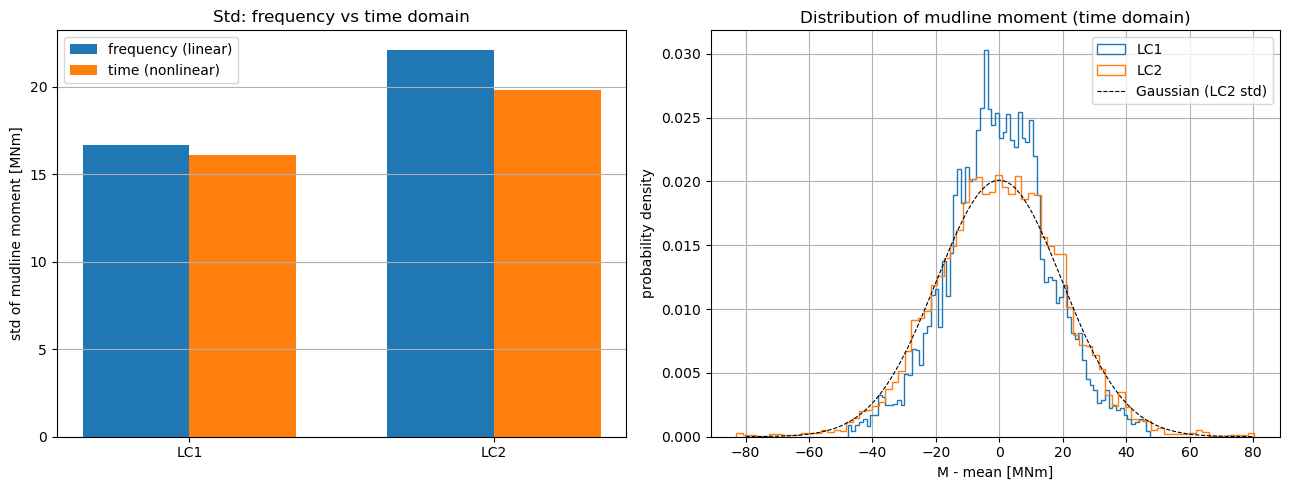

In [28]:
# ====== COMPARISON PLOTS ======
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# (a) std bar chart
x = np.arange(2); w = 0.35
axes[0].bar(x-w/2, [std_f_LC1/1e6, std_f_LC2/1e6], w, label='frequency (linear)')
axes[0].bar(x+w/2, [M_mud_LC1.std()/1e6, M_mud_LC2.std()/1e6], w, label='time (nonlinear)')
axes[0].set_xticks(x); axes[0].set_xticklabels(['LC1', 'LC2'])
axes[0].set_ylabel('std of mudline moment [MNm]')
axes[0].set_title('Std: frequency vs time domain'); axes[0].legend(); axes[0].grid(True, axis='y')
# (b) distribution of the time-domain moment with Gaussian reference
for M, lab in [(M_mud_LC1, 'LC1'), (M_mud_LC2, 'LC2')]:
    axes[1].hist((M-M.mean())/1e6, bins=80, density=True, histtype='step', label=lab)
xx = np.linspace(-80, 80, 200)
axes[1].plot(xx, np.exp(-xx**2/(2*(M_mud_LC2.std()/1e6)**2))/((M_mud_LC2.std()/1e6)*np.sqrt(2*np.pi)),
             'k--', lw=0.8, label='Gaussian (LC2 std)')
axes[1].set_xlabel('M - mean [MNm]'); axes[1].set_ylabel('probability density')
axes[1].set_title('Distribution of mudline moment (time domain)'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

**Conclusions.**
- The two independent methods agree closely (std within ~3% for LC1 and ~10% for LC2; matching
  means and zero-crossing periods), which validates the linear model and the whole workflow.
- The small time-domain reduction is the effect of nonlinear drag / relative-velocity damping
  (positive damping), most visible in the more energetic LC2.
- **Load-case contrast:** although LC2 has more than double the wind speed and significant wave
  height, its fluctuating mudline moment is only ~20–35% larger than LC1's, because LC1 is tuned
  to excite the first resonance. In static terms (mean moment) LC2 is ~4× LC1 — so dynamic
  amplification is what makes the two cases comparable, underlining the importance of dynamic
  analysis. The response is near-Gaussian, so the standard deviation is a meaningful design
  measure (peak factor ~3).

## Step 8 — Assessment of the diffraction assumption
**Objective.** Verify that neglecting diffraction is justified, and argue qualitatively how
including it would change the response.

In [29]:
# ====== DIFFRACTION PARAMETER D/lambda AT THE SPECTRAL PEAK (finite-depth dispersion) ======
def k_of_omega(w):
    return brentq(lambda k: w**2 - g*k*np.tanh(k*h), 1e-6, 10.0)

print(f"{'LC':5}{'Tp [s]':>9}{'lambda_p [m]':>14}{'D/lambda':>10}   diffraction?")
for lc, omega_p, Tp in [('LC1', omega_p_LC1, Tp_LC1), ('LC2', omega_p_LC2, Tp_LC2)]:
    kp = k_of_omega(omega_p)
    lam = 2*np.pi/kp
    ratio = D0/lam
    print(f"{lc:5}{Tp:>9.2f}{lam:>14.1f}{ratio:>10.3f}   {'neglect (<0.2)' if ratio<0.2 else 'consider'}")

print(f"\nMorison validity limit D/lambda=0.2  ->  f <= {f_diff:.3f} Hz")
print(f"both wave peaks (LC1 {1/Tp_LC1:.3f} Hz, LC2 {1/Tp_LC2:.3f} Hz) lie below this limit.")

LC      Tp [s]  lambda_p [m]  D/lambda   diffraction?
LC1       7.16          79.5     0.066   neglect (<0.2)
LC2       9.14         123.9     0.042   neglect (<0.2)

Morison validity limit D/lambda=0.2  ->  f <= 0.245 Hz
both wave peaks (LC1 0.140 Hz, LC2 0.109 Hz) lie below this limit.


**Assessment.** With D = 5.21 m, the diffraction parameter D/λ at the spectral peak is well
below the customary 0.2 threshold for both load cases, so the structure is in the
**inertia-dominated (Morison) regime** and diffraction can be neglected. This is consistent
with the band limit applied to the wave loading in Steps 4–6 (Morison applied only for
f ≤ 0.245 Hz), which excludes exactly the short-wave / large-body regime where diffraction
would matter.

**Effect if included.** Diffraction would modify the wave loading mainly through a reduced,
frequency-dependent effective inertia coefficient for the larger/shorter-wave components. For
the present sea states this correction is small because the energetic waves are long compared
with the cylinder. Including it would slightly alter the near-surface wave force; the response
of both load cases would change only marginally, and the conclusions — wave-dominated, first-
mode-driven response with close frequency/time-domain agreement — would be unchanged.